# Ionic-conductivity parity: PaiNN (FP32) vs OPLS-AA vs experiment

Reproduces `figure_conductivity_parity_2row_no01M.png` - a 2x2 parity grid
(row1 PaiNN / row2 OPLS x Onsager / Nernst-Einstein), sim (mean +/- 1 s.d. over
replicas) vs experiment at 298 K, 0.1 M excluded.

Drawn by `plot_group_transport_parity.py` (in `observable_scripts/group_eval`, pure
pandas/matplotlib). This notebook puts that dir on `sys.path` and calls it.

**Kernel:** any Python with `pandas` + `matplotlib` (e.g. `.../envs/fairchemV2_new`).

In [1]:
import sys
from pathlib import Path
from IPython.display import Image, display

# --- source: the group_eval plotting code (the `src path`) ---
SRC = "/global/homes/y/yuejian/project/MLFF-distill/APPLICATIONS/electrolytes/observable_scripts/group_eval"
if SRC not in sys.path:
    sys.path.insert(0, SRC)
import plot_group_transport_parity as P   # pure pandas / matplotlib, no ase/byteff2

# --- merged transport CSVs ---
PAINN_MERGED = "/global/homes/y/yuejian/project/MLFF-distill/m5250/distillation_proj/simulation_results/PAINN/electrolytes_data/analysis/fp32_simulation/In_distribution/multi_replicas/nvt/merged"   # PaiNN FP32 NVT merged/
OPLS_GROUP   = "/global/homes/y/yuejian/project/MLFF-distill/m5250/distillation_proj/simulation_results/OPLS/analysis/nvt/group_results"   # OPLS-AA group_results/

OUT = str(Path(PAINN_MERGED) / "figure_conductivity_parity_2row_no01M.png")
print("src :", SRC)
print("out :", OUT)

src : /global/homes/y/yuejian/project/MLFF-distill/APPLICATIONS/electrolytes/observable_scripts/group_eval
out : /global/homes/y/yuejian/project/MLFF-distill/m5250/distillation_proj/simulation_results/PAINN/electrolytes_data/analysis/fp32_simulation/In_distribution/multi_replicas/nvt/merged/figure_conductivity_parity_2row_no01M.png


## Produce the parity figure

`--layout cond-2row` builds the 2x2 PaiNN/OPLS x Onsager/NE grid; `--drop-01m`
excludes the 0.1 M systems. Writes `.png` + `.pdf` next to the PaiNN merged CSVs.

saved -> /global/homes/y/yuejian/project/MLFF-distill/m5250/distillation_proj/simulation_results/PAINN/electrolytes_data/analysis/fp32_simulation/In_distribution/multi_replicas/nvt/merged/figure_conductivity_parity_2row_no01M.png  and  /global/homes/y/yuejian/project/MLFF-distill/m5250/distillation_proj/simulation_results/PAINN/electrolytes_data/analysis/fp32_simulation/In_distribution/multi_replicas/nvt/merged/figure_conductivity_parity_2row_no01M.pdf


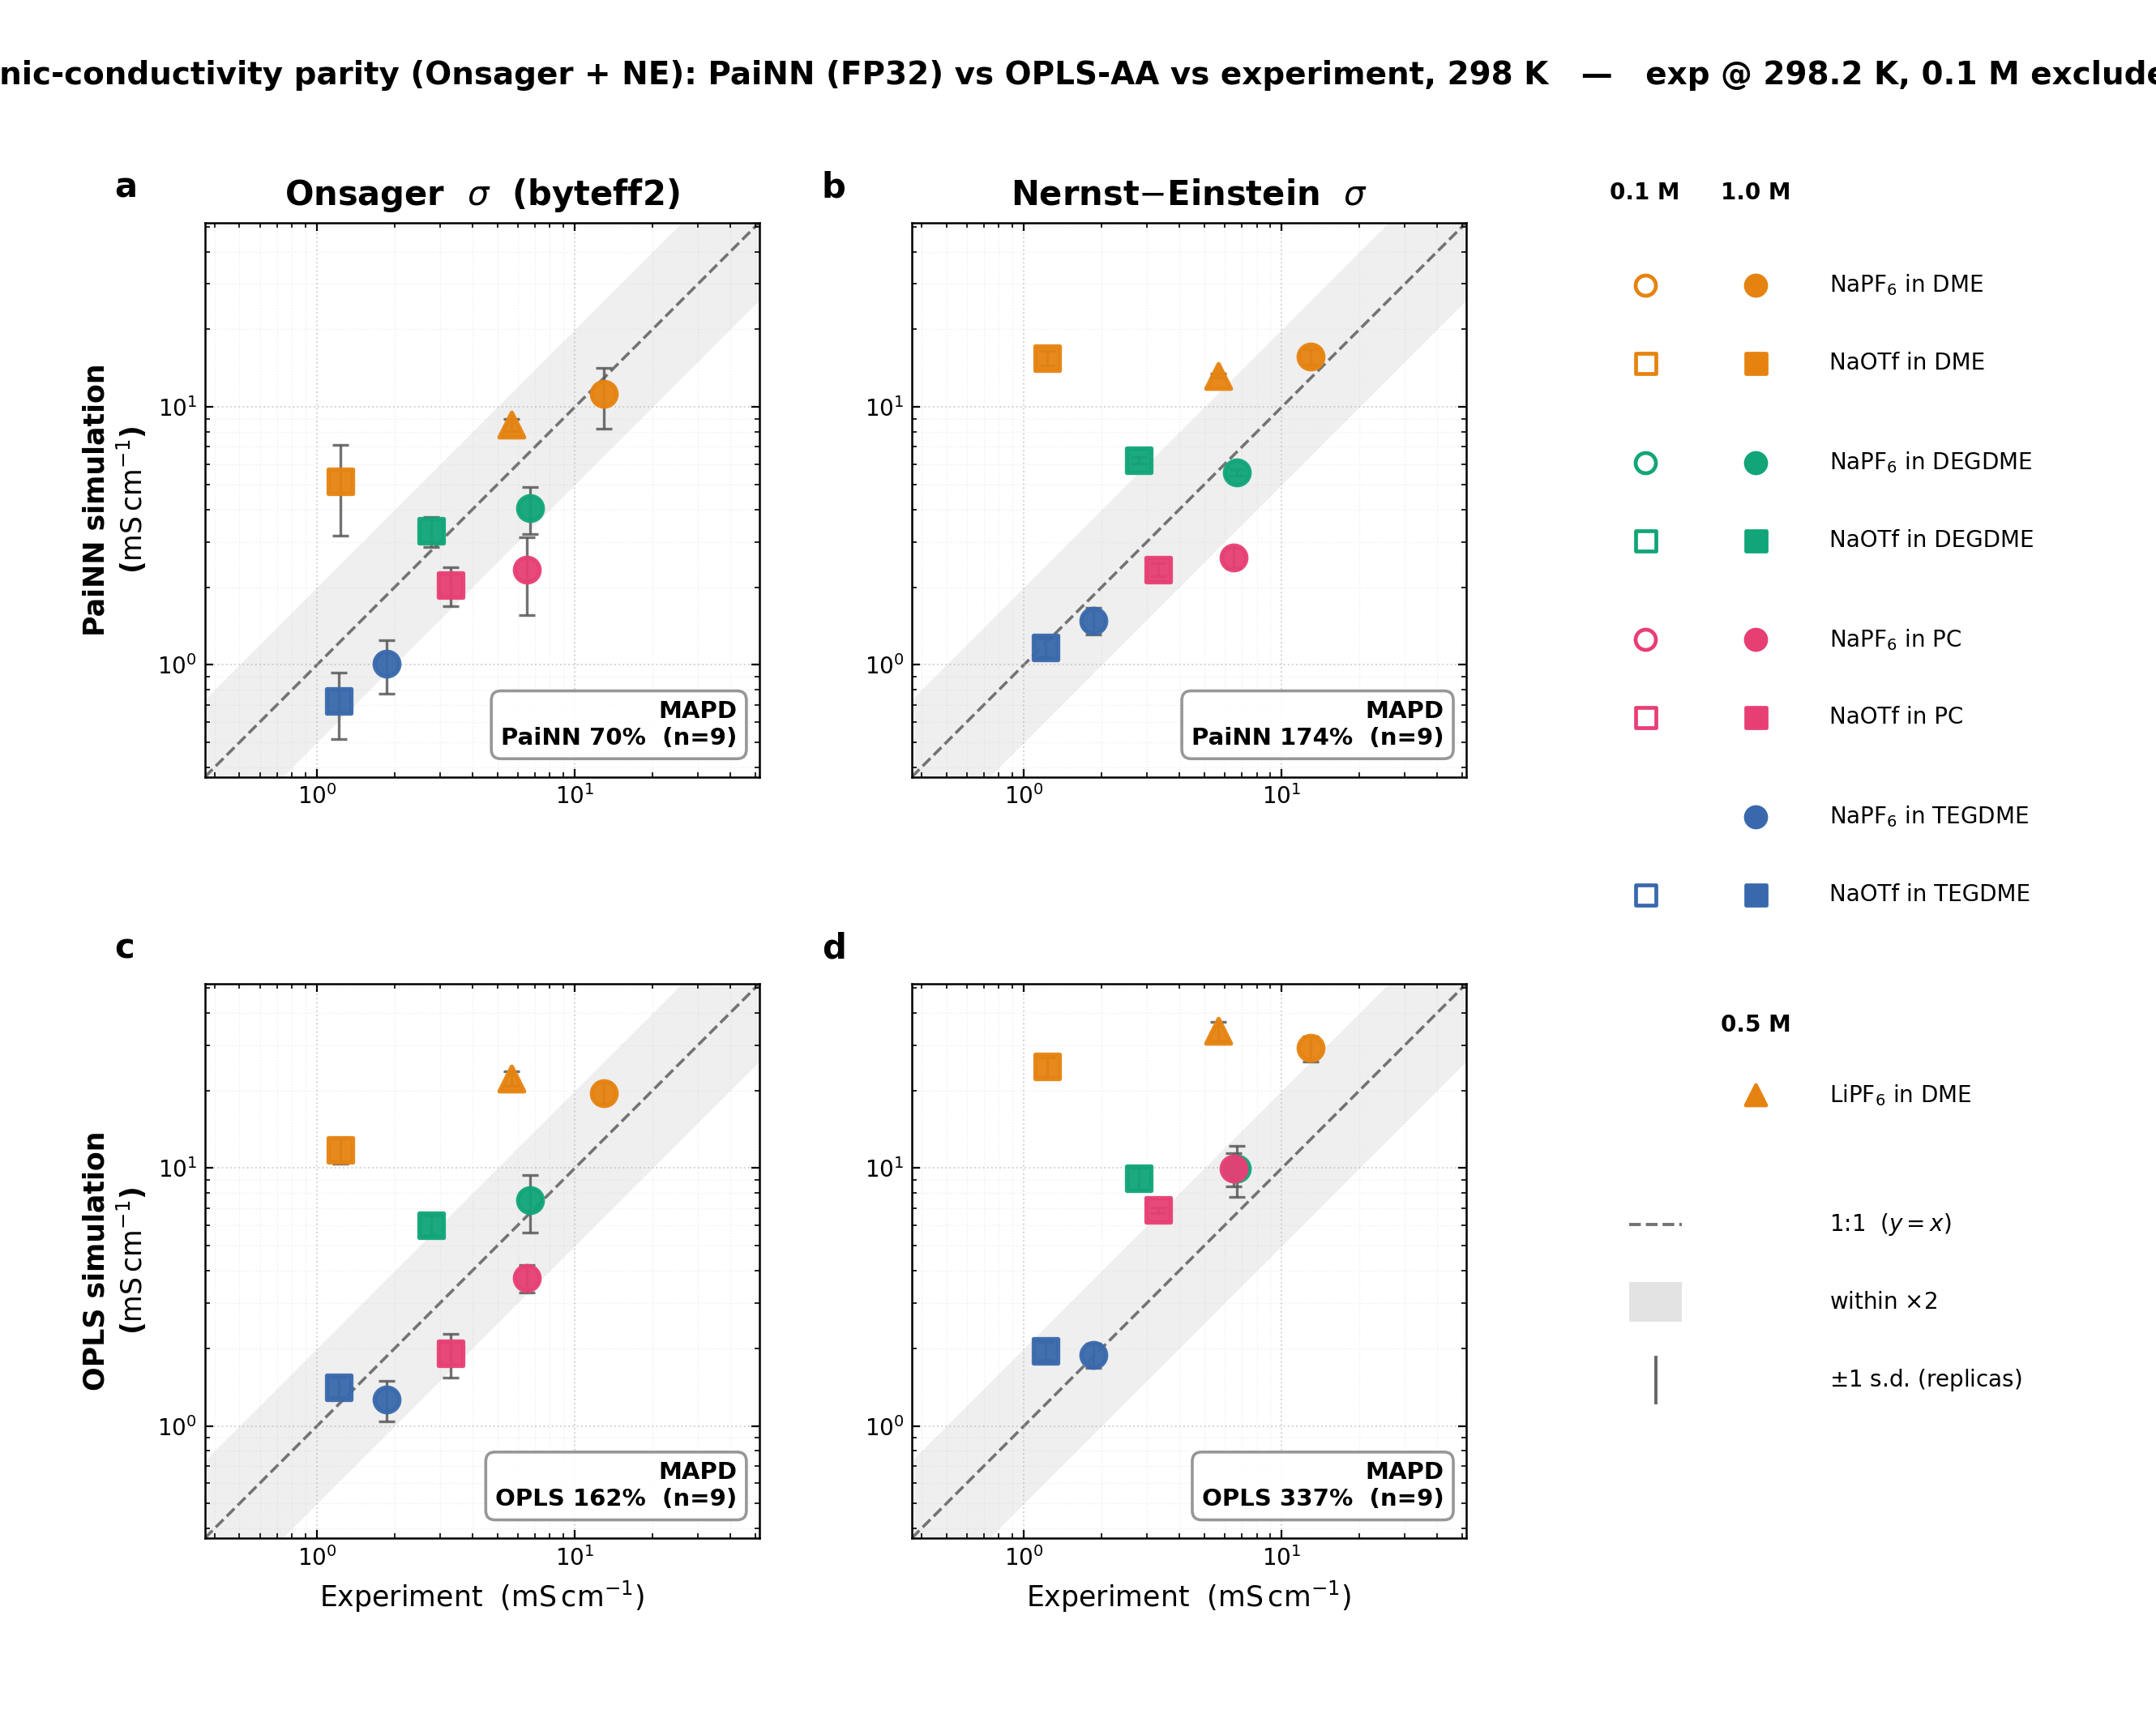

In [2]:
P.main([
    "--merged", PAINN_MERGED,
    "--opls",   OPLS_GROUP,
    "--layout", "cond-2row",   # 2x2: row1 PaiNN, row2 OPLS; cols = Onsager, NE
    "--drop-01m",              # exclude 0.1 M systems
    "--temperature", "298",
    "--out", OUT,
])
display(Image(OUT))

## Variants (optional)

- **Keep 0.1 M**: drop `--drop-01m` (and change `--out`).
- **Onsager only**: add `--drop-ne`.  **Same PaiNN/OPLS row limits**: add `--shared-range`.
- **Pearson r box**: add `--show-r`.  **Hide MAPD**: add `--no-mapd`.

Every option maps 1:1 to a `plot_group_transport_parity.py` CLI flag.

saved -> /global/homes/y/yuejian/project/MLFF-distill/m5250/distillation_proj/simulation_results/PAINN/electrolytes_data/analysis/fp32_simulation/In_distribution/multi_replicas/nvt/merged/figure_conductivity_parity_2row_onsager.png  and  /global/homes/y/yuejian/project/MLFF-distill/m5250/distillation_proj/simulation_results/PAINN/electrolytes_data/analysis/fp32_simulation/In_distribution/multi_replicas/nvt/merged/figure_conductivity_parity_2row_onsager.pdf


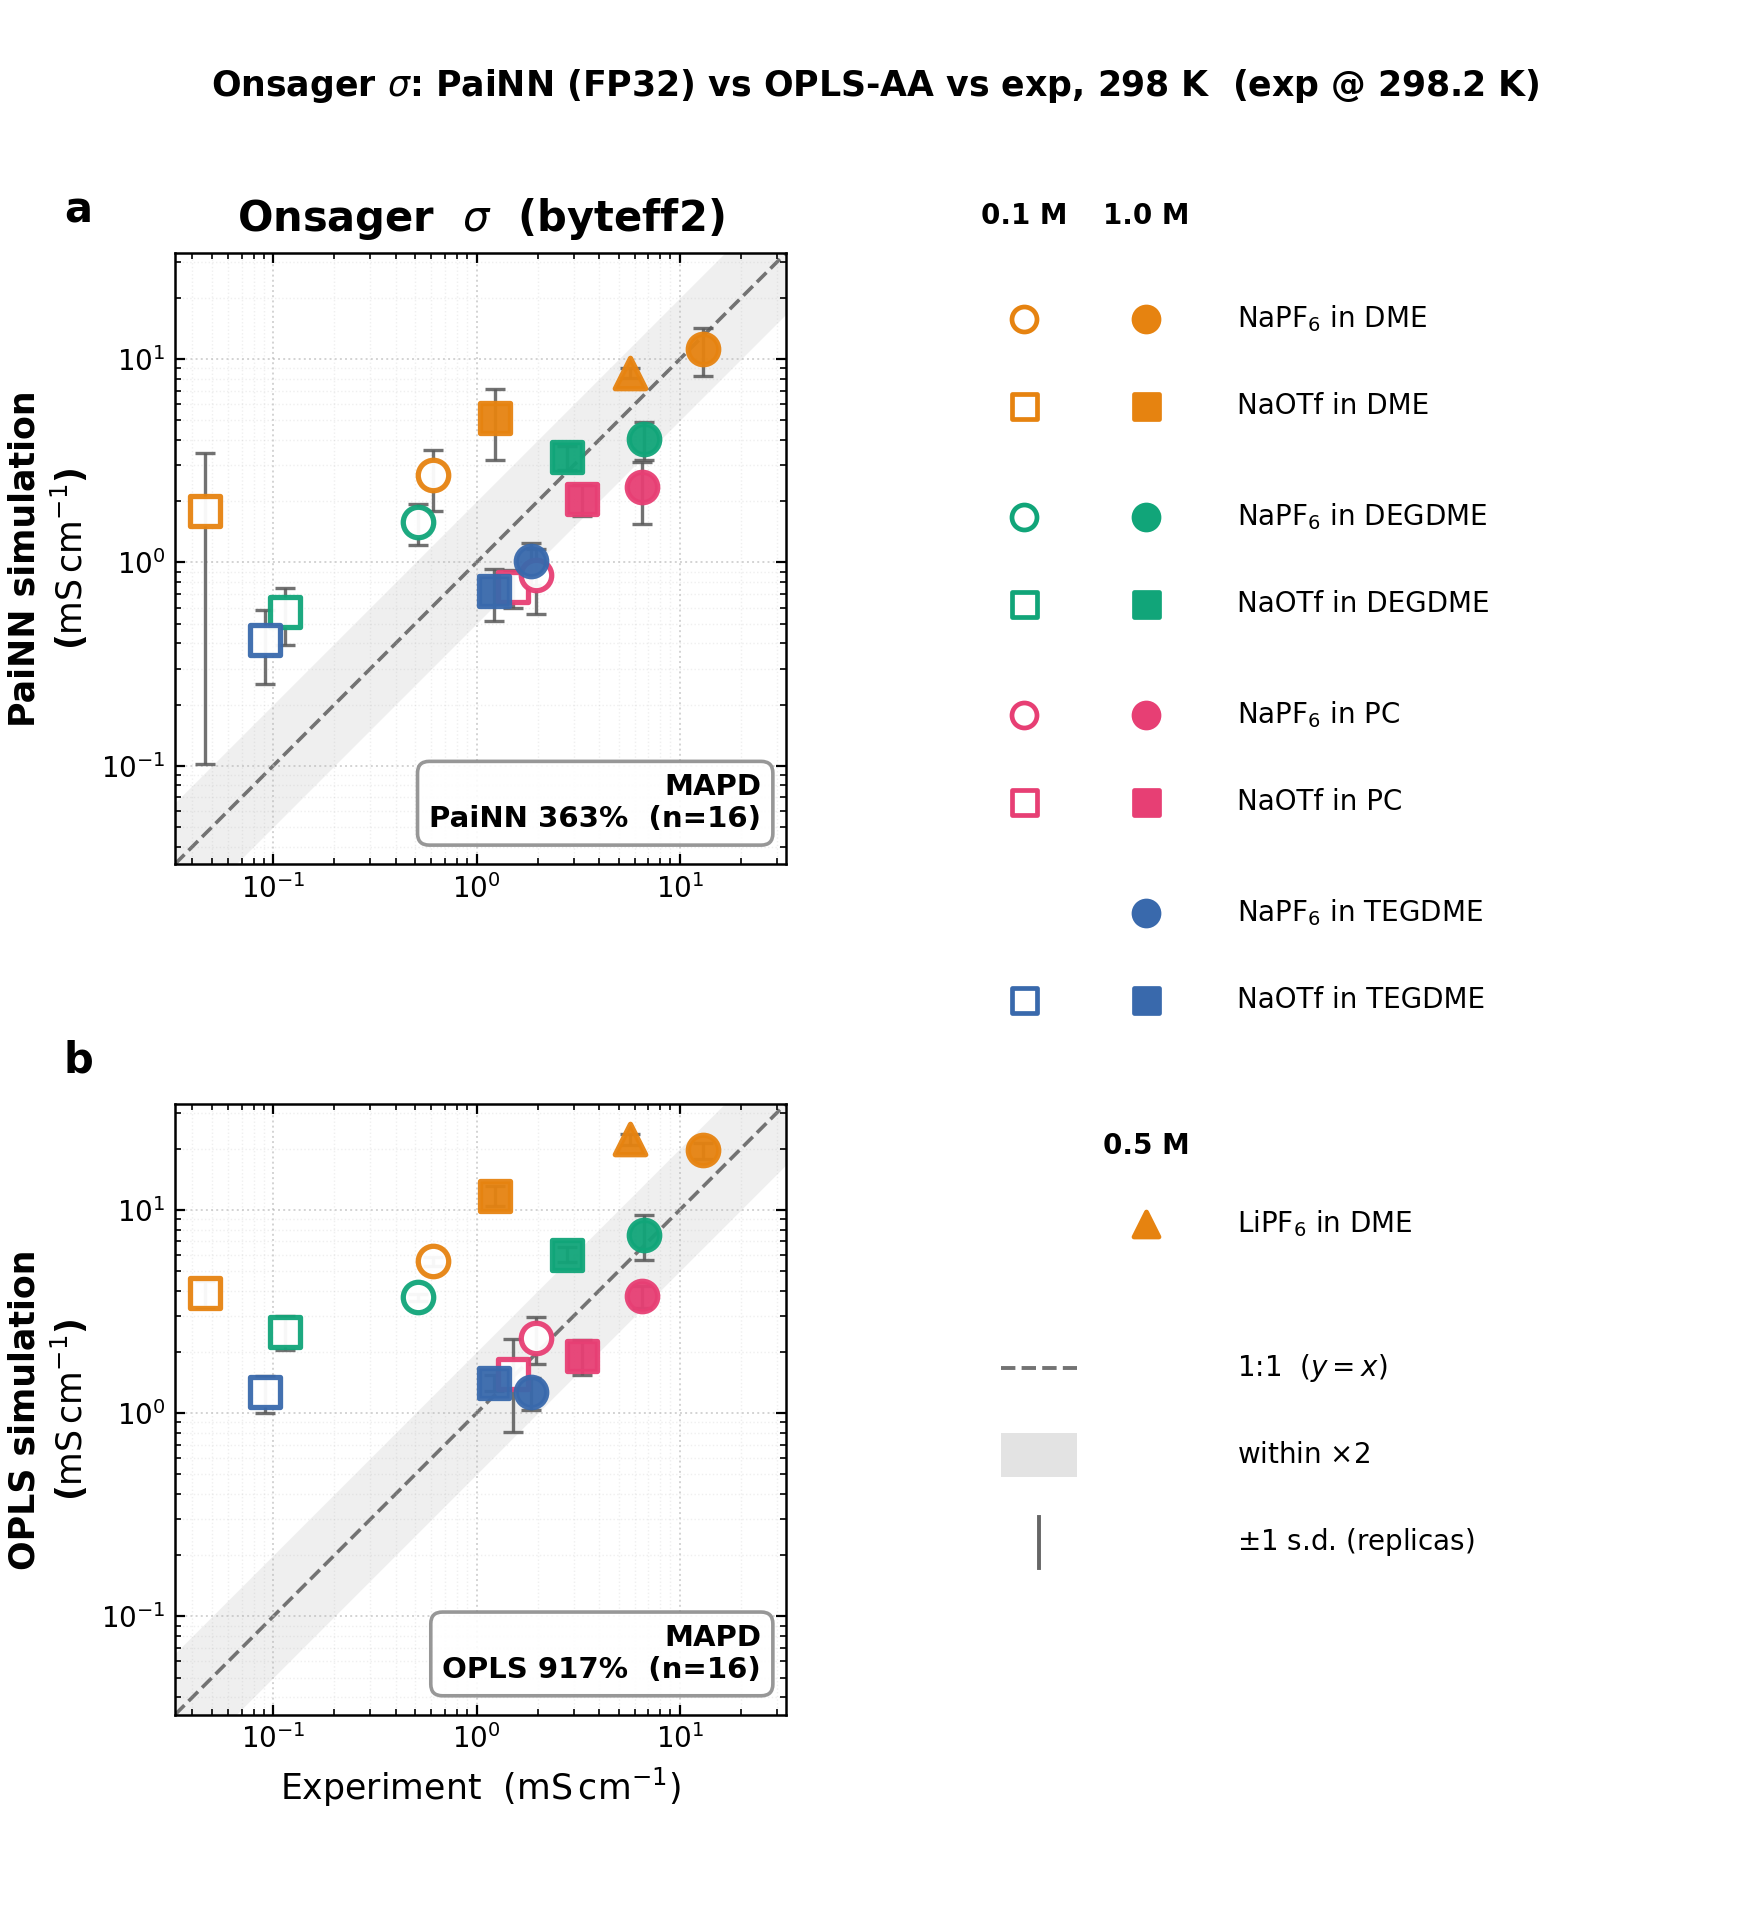

In [3]:
# Example variant: Onsager-only, keep all concentrations
OUT_ONS = str(Path(PAINN_MERGED) / "figure_conductivity_parity_2row_onsager.png")
P.main([
    "--merged", PAINN_MERGED, "--opls", OPLS_GROUP,
    "--layout", "cond-2row", "--drop-ne", "--temperature", "298",
    "--out", OUT_ONS,
])
display(Image(OUT_ONS))

## Conductivity mismatch vs experimental ionicity  (Onsager, |relative error|)

Magnitude of the **Onsager** conductivity error, $\left|(\sigma_\mathrm{sim}-\sigma_\mathrm{exp})/\sigma_\mathrm{exp}\right|$, 
vs the **experimental ionicity** (inverse Haven ratio)

$$\text{ionicity} = \sigma^{\mathrm{exp}}_{\mathrm{onsager}}\,/\,\sigma^{\mathrm{exp}}_{\mathrm{NE}}$$

with $\sigma^{\mathrm{exp}}_{\mathrm{onsager}}$ the **measured** conductivity and $\sigma^{\mathrm{exp}}_{\mathrm{NE}}$ the **Nernst-Einstein** conductivity from the **experimental**
cation+anion self-diffusivities ($\sigma_{\mathrm{NE}}=\frac{e^2 n}{k_B T}(D_{+}+D_{-})$, 1:1 salt, nominal number density $n$).

Only the byteff2 **Onsager** estimator is shown. Negative relative errors (under-prediction) are
plotted as their **absolute value** so the magnitude sits on a log $y$-axis; the signed value is
kept in the table below. Encoding: solvent -> colour, salt -> marker, 0.1 M -> hollow. 298 K;
systems without an experimental diffusivity (e.g. NaPF6/TEGDME) drop out of the ionicity axis.

**Reading it:** $|$error$|$ is largest at low ionicity (strongly-associated systems, where the sim grossly
*over*-predicts) and rises again for well-dissociated systems (where it *under*-predicts ~0.5); the
dip in between is where the signed error crosses zero.

,system_id,concentration_M,ionicity,mismatch_onsager,abs_mismatch_onsager
0,naotf_dme,0.1,0.005,37.736,37.736
1,naotf_diglyme,0.1,0.024,3.999,3.999
2,naotf_dme,1.0,0.029,3.178,3.178
3,napf6_dme,0.1,0.047,3.392,3.392
4,naotf_tgdme,0.1,0.087,3.574,3.574
5,napf6_diglyme,0.1,0.113,2.044,2.044
6,naotf_diglyme,1.0,0.136,0.190,0.190
7,lipf6_dme,0.5,0.203,0.504,0.504
8,naotf_tgdme,1.0,0.219,-0.405,0.405
9,napf6_dme,1.0,0.267,-0.133,0.133


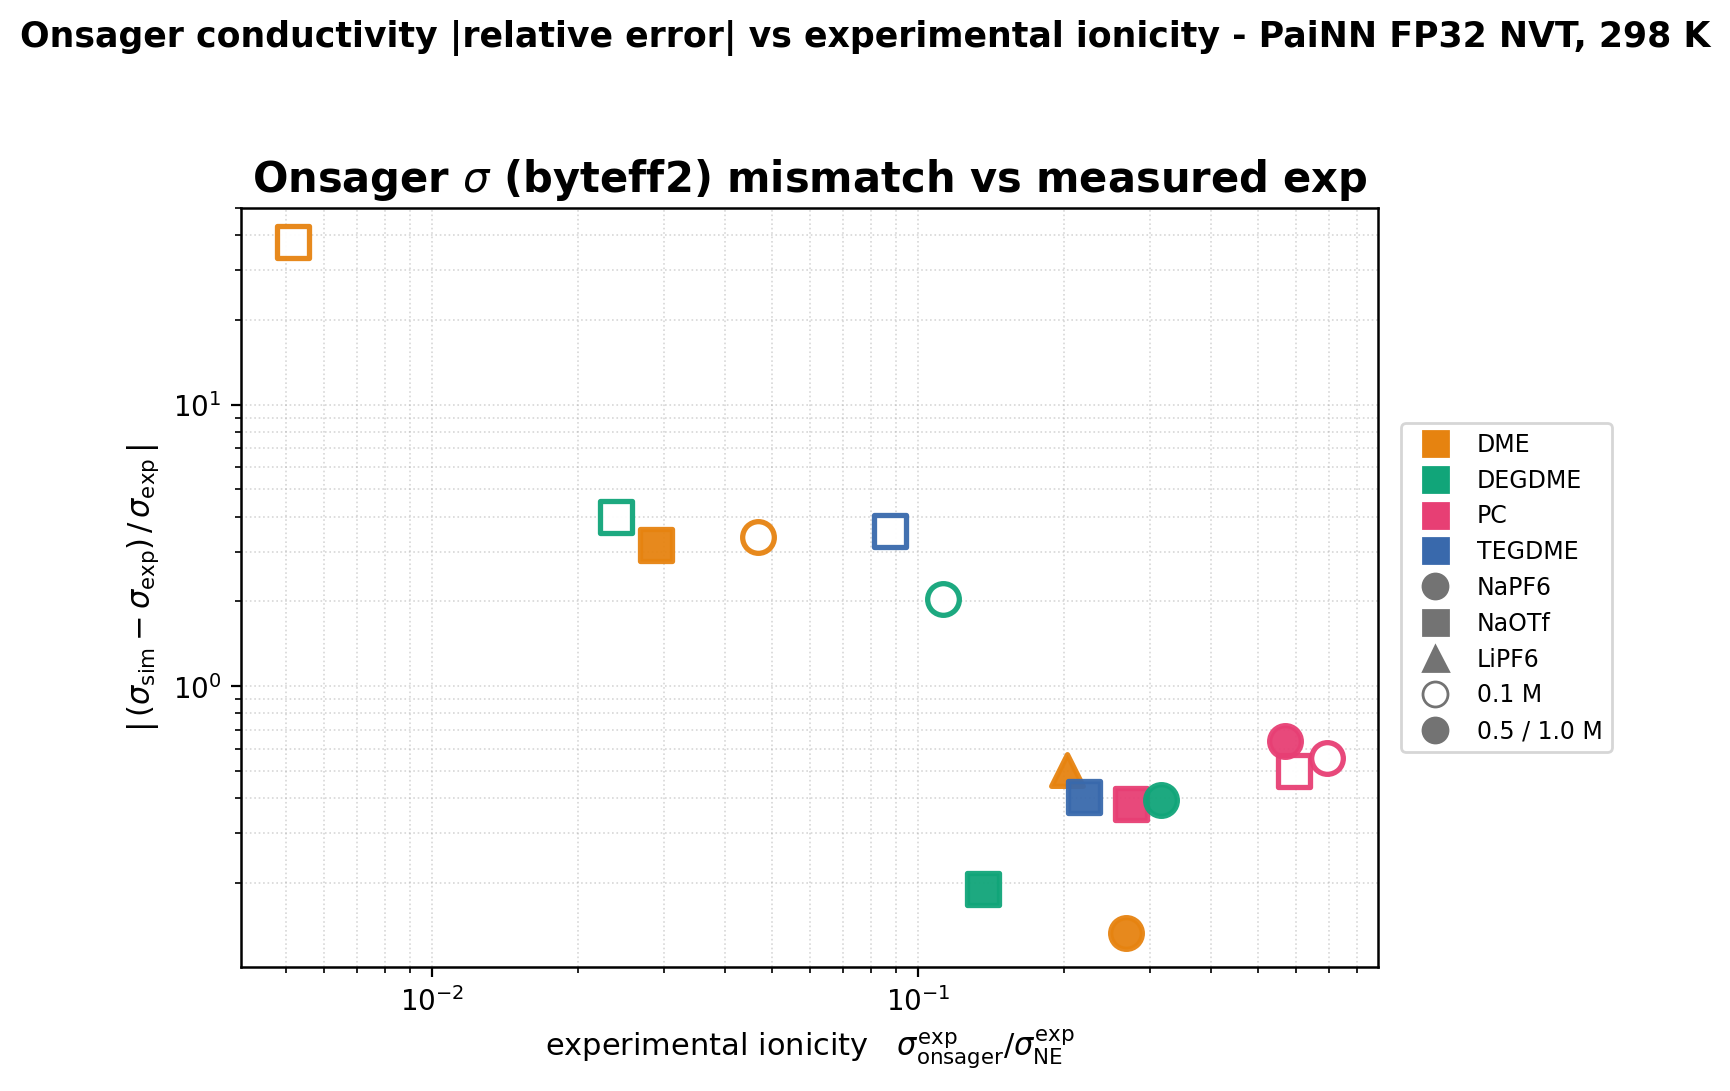

In [5]:
# plot conductivity mismatch (sigma_sim - sigma_exp)/sigma_exp over exp \sigma_onsager/\sigma_ne, where exp \sigma_onsager is just exp conductivity, and exp\sigma_ne is calculate from ne relation based on exp diffusivity
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Image, display

# house style (solvent colour / salt marker) from the same src module
from plot_group_transport_parity import SOLV_COLOR, SALT_MARKER, _salt_solv

# --- merged by-system transport CSVs (PaiNN FP32 NVT) ---
c = pd.read_csv(f"{PAINN_MERGED}/conductivity_by_system.csv")
d = pd.read_csv(f"{PAINN_MERGED}/diffusivity_by_system.csv")
df = c.merge(d, on=["system_id", "concentration_M", "temperature_K"], how="outer")

# --- Nernst-Einstein conductivity (1:1 salt, z=+-1) -> mS/cm ---
E = 1.602176634e-19; KB = 1.380649e-23; NA = 6.02214076e23
def sigma_NE(Dp, Dm, conc_M, T):
    """standard NE from cation+anion self-D (units 1e-10 m^2/s) and nominal
    number density conc_M -> mS/cm."""
    n = conc_M * 1000.0 * NA                 # ion pairs per m^3
    return E**2 * n / (KB * T) * ((Dp + Dm) * 1e-10) * 10.0

TEMP = 298.0
df = df[np.abs(df.temperature_K - TEMP) < 1.0].copy()

# experimental references + ionicity (x-axis). exp_sigma_NE is the denominator, still needed.
df["exp_sigma_onsager"] = df.exp_conductivity_mS_cm                       # measured conductivity
df["exp_sigma_NE"]      = sigma_NE(df.exp_D_cation_ref, df.exp_D_anion_ref,
                                   df.concentration_M, df.temperature_K)  # NE from EXP diffusivity
df["ionicity"] = df.exp_sigma_onsager / df.exp_sigma_NE

# Onsager relative error; take |.| so negatives (under-prediction) sit on a log axis
df["mismatch_onsager"]     = (df["sigma_onsager_mS_cm_mean"] - df.exp_sigma_onsager) / df.exp_sigma_onsager
df["abs_mismatch_onsager"] = df["mismatch_onsager"].abs()
plot_df = df[df.ionicity.notna()].copy()
# plot_df.drop(1)
# --- plot: |Onsager relative error| vs experimental ionicity (single panel) ---
def _style(row):
    salt, solv = _salt_solv(row.system_id)
    return SOLV_COLOR.get(solv, "0.4"), SALT_MARKER.get(salt, "o"), float(row.concentration_M) != 0.1

fig, ax = plt.subplots(figsize=(7.8, 5.6))
for _, r in plot_df.iterrows():
    color, marker, filled = _style(r)
    ax.scatter(r.ionicity, r.abs_mismatch_onsager, s=130, marker=marker,
               facecolor=color if filled else "white",
               edgecolor=color, linewidths=1.9, alpha=0.95, zorder=3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"experimental ionicity   $\sigma^{\mathrm{exp}}_{\mathrm{onsager}}/\sigma^{\mathrm{exp}}_{\mathrm{NE}}$",
              fontsize=11)
ax.set_ylabel(r"$\left|\,(\sigma_{\mathrm{sim}}-\sigma_{\mathrm{exp}})\,/\,\sigma_{\mathrm{exp}}\,\right|$",
              fontsize=11)
ax.set_title(r"Onsager $\sigma$ (byteff2) mismatch vs measured exp", fontweight="bold")
ax.grid(True, which="both", ls=":", lw=0.6, alpha=0.5)

solv_h = [Line2D([0], [0], marker="s", ls="", mfc=SOLV_COLOR[k], mec=SOLV_COLOR[k], ms=9, label=n)
          for n, k in [("DME", "dme"), ("DEGDME", "diglyme"), ("PC", "pc"), ("TEGDME", "tgdme")]]
salt_h = [Line2D([0], [0], marker=m, ls="", mfc="0.45", mec="0.45", ms=9, label=n)
          for n, m in [("NaPF6", "o"), ("NaOTf", "s"), ("LiPF6", "^")]]
fill_h = [Line2D([0], [0], marker="o", ls="", mfc="white", mec="0.45", ms=9, label="0.1 M"),
          Line2D([0], [0], marker="o", ls="", mfc="0.45", mec="0.45", ms=9, label="0.5 / 1.0 M")]
ax.legend(handles=solv_h + salt_h + fill_h, fontsize=8.5, loc="center left",
          bbox_to_anchor=(1.01, 0.5), frameon=True)
fig.suptitle(f"Onsager conductivity |relative error| vs experimental ionicity - PaiNN FP32 NVT, {TEMP:.0f} K",
             fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))

OUT_MM = "/global/homes/y/yuejian/project/MLFF-distill/draft/conductivity/figure_conductivity_mismatch_vs_ionicity.png"
fig.savefig(OUT_MM, dpi=200, bbox_inches="tight")
fig.savefig(OUT_MM.replace(".png", ".pdf"), bbox_inches="tight")
plt.close(fig)

# numbers behind the figure (signed mismatch kept alongside the plotted |.|)
show = ["system_id", "concentration_M", "ionicity", "mismatch_onsager", "abs_mismatch_onsager"]
display(plot_df[show].sort_values("ionicity").round(3).reset_index(drop=True))
display(Image(OUT_MM))